# R5 — Evaluación final: única apertura del conjunto de test

**Este notebook se ejecuta una sola vez, al final.** El modelo y el umbral ya
quedaron fijados en R4 sobre validation. Aquí no se ajusta nada: solo se mide.

Volver atrás y cambiar algo después de leer estos resultados convierte el test
en un segundo conjunto de validación e invalida las estimaciones.

## Qué se reporta

* PR-AUC, ROC-AUC, recall, precisión y F1 con **IC 95 % por bootstrap**.
* **recall@P=0,90** — la métrica con la que la v1 descartó AutoML sin calcularla
  nunca para su propio modelo.
* **Carga operativa**: alertas y falsas alertas por cada 100.000 sesiones.
* Brecha validation → test, que es el indicador honesto de sobreajuste de
  selección.

In [1]:
# Celda de arranque idéntica en todos los notebooks. Deja el kernel de SageMaker
# en un estado conocido: mismo directorio de trabajo, mismas semillas, mismas
# versiones. Si algo de esto cambia entre corridas, los resultados no son
# comparables aunque los notebooks sean los mismos.
import sys, os

AQUI = os.getcwd()                    # los notebooks y vishing_common.py conviven
if AQUI not in sys.path:
    sys.path.insert(0, AQUI)

import numpy as np
import pandas as pd
import vishing_common as vc

vc.set_all_seeds()                    # random, numpy y torch (+ cuDNN determinista)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("dataset:", vc.RAW_FILENAME, "(esquema", vc.DATASET_VERSION + ")")
print("bucket :", vc.BUCKET, "| prefijo:", vc.PREFIX)
print("seed   :", vc.SEED, "| split:", vc.SPLIT_MODE, "| política:", vc.FEATURE_POLICY)
print("xgboost se ejecutará en:", vc.xgb_device())
vc.check_versions()

dataset: biocatch_sinthetic_data_v3.csv (esquema v3)
bucket : poc-vishing | prefijo: v2
seed   : 42 | split: grouped | política: audited
xgboost se ejecutará en: cuda
  versiones OK: numpy 2.0.2, pandas 2.2.3, scipy 1.14.1, sklearn 1.5.2, imblearn 0.12.4, xgboost 2.1.4


,paquete,instalada,esperado,ok
0,numpy,2.0.2,">=1.26,<2.1",True
1,pandas,2.2.3,">=2.1,<2.3",True
2,scipy,1.14.1,">=1.11,<1.15",True
3,sklearn,1.5.2,">=1.4,<1.6",True
4,imblearn,0.12.4,">=0.12,<0.13",True
5,xgboost,2.1.4,">=2.0,<2.2",True


In [2]:
cfg = vc.read_json(vc.P.feature_contract)
contract = cfg["contratos"][cfg["activo"]]

ganador = vc.read_json(vc.P.val_leaderboard.replace(
    "validation_leaderboard.csv", "ganador.json"))["ganador"]
print("modelo seleccionado en R4:")
for k, v in ganador.items():
    print("  %-12s: %s" % (k, v))

envoltorio = vc.read_pickle(vc.P.model(ganador["data_type"], ganador["variante"],
                                       ganador["technique"], ganador["ratio"]))
print()
print(envoltorio)
print("umbral fijado sobre:", envoltorio.metadata.get("threshold_fitted_on"))
assert envoltorio.metadata.get("threshold_fitted_on") == "validation", \
    "el umbral no se fijó sobre validation"

modelo seleccionado en R4:
  data_type   : original
  technique   : none
  ratio       : 0
  variante    : xgb_shallow
  umbral      : 0.8464
  pr_auc      : 0.8504
  roc_auc     : 0.9745
  recall      : 0.8218
  precision   : 0.8065
  f1          : 0.8141
  recall_p90  : 0.6146

VishingModelWrapper(xgb_shallow/none/0, 44 features, thr=0.8464)
umbral fijado sobre: validation


In [3]:
test = vc.read_parquet(vc.P.test)
print("test:", test.shape, "| vishing: %.4f (%d casos)"
      % (test[vc.TARGET].mean(), test[vc.TARGET].sum()))

# Última verificación de integridad antes de medir
for nombre, ruta in [("train", vc.P.train), ("train aumentado", vc.P.train_augmented)]:
    try:
        vc.assert_disjoint(vc.read_parquet(ruta), test, "%s vs test" % nombre)
    except AssertionError:
        raise                       # una fuga sí debe detener la evaluación
    except Exception as e:
        # S3 devuelve FileNotFoundError con s3fs pero ClientError por boto3
        print("  (%s no disponible, se omite: %s)" % (nombre, type(e).__name__))

test: (20193, 60) | vishing: 0.0491 (992 casos)
  OK sin fuga [train vs test]: 60,134 train / 20,193 eval, disjuntos
  OK sin fuga [train aumentado vs test]: 560,134 train / 20,193 eval, disjuntos


## Medición

In [4]:
Xte = test[contract["features"]].fillna(0).values
yte = test[vc.TARGET].values

Xte_ = envoltorio.scaler.transform(Xte) if envoltorio.scaler is not None else Xte
pte = envoltorio.model.predict_proba(Xte_)[:, 1]

rep_test = vc.full_report(yte, pte, envoltorio.threshold, n_boot=1000, seed=vc.SEED)
vc.print_report(rep_test, "TEST — %s / %s / %s / %s"
                % (ganador["data_type"], ganador["variante"],
                   ganador["technique"], ganador["ratio"]))

/home/ec2-user/SageMaker/vishing-remediation/vishing-venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [18:31:00] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



  TEST — original / xgb_shallow / none / 0
----------------------------------------------------------------
  n = 20,193   positivos = 992 (4.91%)   umbral = 0.8464
----------------------------------------------------------------
  pr_auc    : 0.8458  [0.8266, 0.8652]
  roc_auc   : 0.9673  [0.9601, 0.9739]
  recall    : 0.7903  [0.7651, 0.8165]
  precision : 0.8025  [0.7785, 0.8246]
  f1        : 0.7963  [0.7770, 0.8156]
  matriz    : TN=19,008  FP=193  FN=208  TP=784
  recall@P=0.90: 0.6472
  por 100k sesiones: 4838 alertas, 956 falsas, 1030 vishing perdido
  PR-AUC de referencia (clasificador aleatorio): 0.0491


In [5]:
val = vc.read_parquet(vc.P.val)
Xv = val[contract["features"]].fillna(0).values
Xv_ = envoltorio.scaler.transform(Xv) if envoltorio.scaler is not None else Xv
pv = envoltorio.model.predict_proba(Xv_)[:, 1]
rep_val = vc.full_report(val[vc.TARGET].values, pv, envoltorio.threshold, n_boot=0)

comp = pd.DataFrame({
    "validation": {k: round(rep_val[k], 4) for k in
                   ["pr_auc", "roc_auc", "recall", "precision", "f1"]},
    "test": {k: round(rep_test[k], 4) for k in
             ["pr_auc", "roc_auc", "recall", "precision", "f1"]},
})
comp["brecha"] = (comp.validation - comp.test).round(4)
display(comp)

print("\nUna brecha grande en PR-AUC indica que la selección entre todos los")
print("modelos de R4 se sobreajustó a validation. Es información honesta que")
print("debe reportarse en el paper, no un error a corregir.")

,validation,test,brecha
pr_auc,0.8504,0.8458,0.0046
roc_auc,0.9745,0.9673,0.0072
recall,0.8218,0.7903,0.0315
precision,0.8065,0.8025,0.0040
f1,0.8141,0.7963,0.0178



Una brecha grande en PR-AUC indica que la selección entre todos los
modelos de R4 se sobreajustó a validation. Es información honesta que
debe reportarse en el paper, no un error a corregir.


## Punto de operación alternativo: precisión 90 %

In [6]:
r90 = rep_test["recall_at_precision_90"]
if r90["alcanzable"]:
    yp90 = (pte >= r90["threshold"]).astype(int)
    print("Con umbral %.4f para precisión >= 0.90:" % r90["threshold"])
    print("  recall: %.4f" % r90["recall"])
    for k, v in vc.alerts_per_100k(yte, yp90).items():
        print("  %-28s: %s" % (k, v))
else:
    print("Ningún umbral alcanza precisión de 0.90 sobre el test.")
    print("Es el mismo criterio con el que la v1 descartó AutoML; si el modelo")
    print("dirigido tampoco lo alcanza, esa comparación debe reformularse.")

Con umbral 0.9734 para precisión >= 0.90:
  recall: 0.6472
  alertas_por_100k            : 3530.9
  falsas_alertas_por_100k     : 351.6
  vishing_perdido_por_100k    : 1733.3


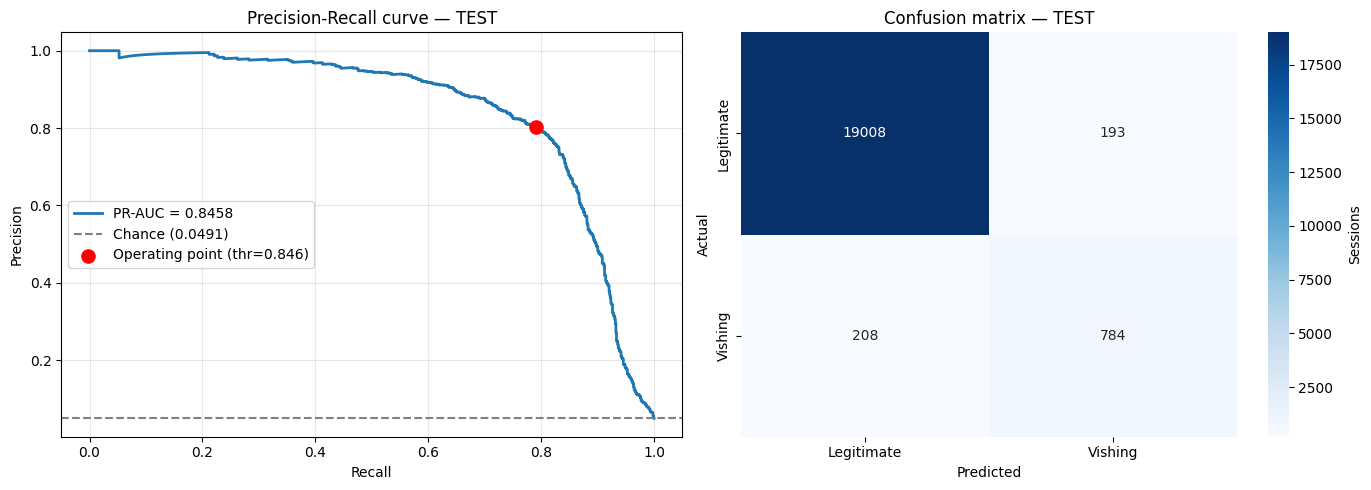

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix
import seaborn as sns

prec, rec, thr = precision_recall_curve(yte, pte)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(rec, prec, lw=2, label="PR-AUC = %.4f" % rep_test["pr_auc"])
ax[0].axhline(yte.mean(), ls="--", c="gray", label="Chance (%.4f)" % yte.mean())
i = int(np.argmin(np.abs(thr - envoltorio.threshold)))
ax[0].scatter([rec[i]], [prec[i]], c="red", zorder=5, s=90,
              label="Operating point (thr=%.3f)" % envoltorio.threshold)
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Precision-Recall curve — TEST"); ax[0].legend(); ax[0].grid(alpha=.3)

cm = confusion_matrix(yte, (pte >= envoltorio.threshold).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["Legitimate", "Vishing"],
            yticklabels=["Legitimate", "Vishing"],
            cbar_kws={"label": "Sessions"})
ax[1].set_title("Confusion matrix — TEST")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [8]:
salida = {"modelo": ganador, "test": rep_test,
          "validation": {k: rep_val[k] for k in
                         ["pr_auc", "roc_auc", "recall", "precision", "f1"]},
          "brecha_val_test": {k: float(comp.loc[k, "brecha"]) for k in comp.index},
          "contrato": {"policy": contract["policy"], "n_features": contract["n_features"],
                       "removed": contract["removed"]},
          "manifiesto": vc.env_manifest()}
vc.write_json(salida, vc.P.final_test)
print("R5 completo. El test queda cerrado.")

  escrito s3://poc-vishing/v2/06_results/final_test.json
R5 completo. El test queda cerrado.
